# Lote US-030 a US-040 (3/3) — Ensambles

**Que veras aqui (datos REALES):** los 4 ensambles base de la rubrica (Voting, Bagging, Stacking, Blending) corridos sobre las predicciones OOF reales del fold-5, la comparativa que justifica el elegido, y las figuras interpretadas (confusion, ROC, residuos espaciales).

Cubre **US-040**.

In [1]:
# Parametros (papermill). Las figuras ya estan generadas con datos reales.


In [2]:
import json
from pathlib import Path

import polars as pl
from IPython.display import Markdown, display

from ml.utils.notebook_setup import find_repo_root, show_saved_png

REPO = find_repo_root()
FIG_DIR = REPO / 'reports/lote_us030_040/figures'
MANIFEST = json.loads((FIG_DIR / 'manifest.json').read_text(encoding='utf-8'))
print('repo:', REPO)
print('figuras:', FIG_DIR, '| existe:', FIG_DIR.is_dir())


repo: C:\Users\arthu\Proyectos\MNA\agro_sat_copilot
figuras: C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\lote_us030_040\figures | existe: True


## Recordatorio de siglas

El glosario completo (todas las siglas + conceptos) esta en [`06a_segmentadores_us030_038_039.ipynb`](06a_segmentadores_us030_038_039.ipynb). Aqui un recordatorio de las mas usadas:

| Sigla | Que significa |
|---|---|
| `GT` | Ground Truth (verdad de campo): la etiqueta correcta de referencia. |
| `mIoU` | mean Intersection over Union: promedio del solapamiento entre prediccion y verdad por clase (0 = nada, 1 = perfecto). Metrica estandar de segmentacion. |
| `F1-macro` | Promedio simple del F1 (media armonica de precision y exhaustividad) sobre todas las clases; trata igual a clases raras y comunes. |
| `CLS` | Token de Clasificacion (Class token): el vector resumen de toda la imagen que produce un Vision Transformer. |
| `OOF` | Out-Of-Fold: predicciones hechas sobre datos que el modelo NO vio al entrenar (evita el auto-engano / fuga de informacion). |
| `MPCL` | Multi-Positive Contrastive Loss: perdida contrastiva que agrupa varios ejemplos positivos de la misma categoria (nucleo del FarSLIP fiel). |
| `fold` | Particion del dataset. PASTIS trae 5 folds espacialmente separados. |
| `held-out` | Fold reservado, nunca usado en entrenamiento, para la evaluacion final. |

## User Story cubierta

- **US-040** — Cuatro ensambles base (Voting/Bagging/Stacking/Blending): Stacking 0.747 elegido, supera al mejor individual.

## Que es un ensamble y por que conviene

Un ensamble combina varios modelos para superar al mejor individual. Probamos los cuatro de la rubrica:

- **Voting** (pixel): promedio de las probabilidades de 3 segmentadores.
- **Bagging** (parcela): XGBoost sobre AlphaEarth con varios bootstraps.
- **Stacking** (parcela): un meta-modelo aprende a combinar 3 base learners heterogeneos (2 temporales densos + 1 tabular).
- **Blending** (parcela): pesos optimos sobre un holdout disjunto.

Todo con **anti-fuga estricto**: solo fold-5, probabilidades post-softmax (nunca logits), meta-modelo solo sobre OOF.

## Comparativa real y modelo elegido

Tabla real (fold-5 held-out): el **Stacking heterogeneo** gana con F1-macro **0.747** y supera al mejor individual (TSViT-pheno 0.625).

**Comparativa de ensambles (verde = elegido: Stacking).**

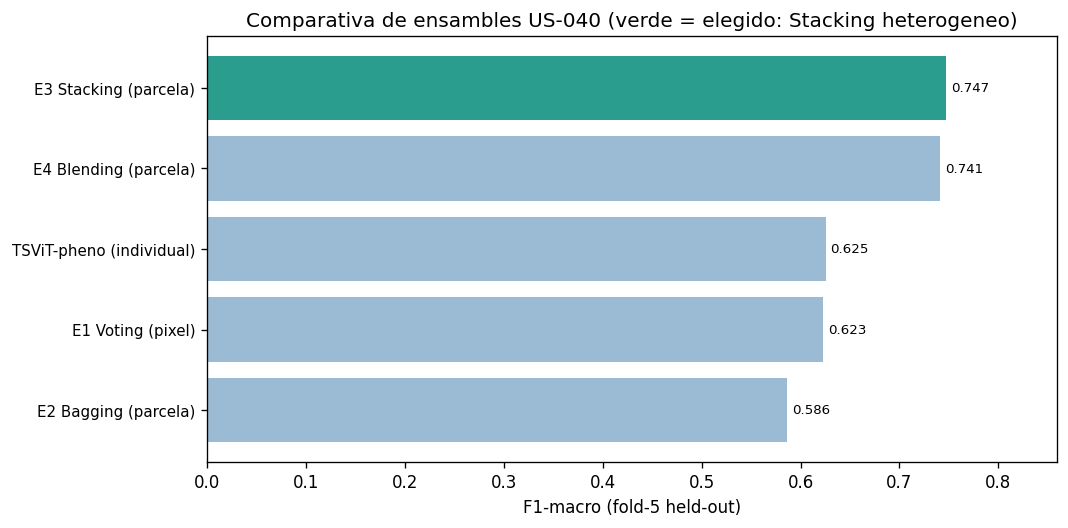

model,f1_macro,accuracy,inference_time_s,chosen
str,f64,f64,f64,bool
"""E3 Stacking (parcela)""",0.747045,0.849038,0.042418,true
"""E4 Blending (parcela)""",0.741387,0.861779,0.006438,false
"""TSViT-pheno (individual)""",0.6253,NaN,NaN,false
"""E1 Voting (pixel)""",0.622523,0.808954,42.488529,false
"""E2 Bagging (parcela)""",0.586381,0.78155,5.496643,false


In [3]:
import polars as pl
show_saved_png(FIG_DIR / MANIFEST['ensemble']['figure'], caption='Comparativa de ensambles (verde = elegido: Stacking).')
rows = MANIFEST.get('ensemble', {}).get('rows', [])
if rows:
    display(pl.DataFrame(rows))


## Figuras interpretadas del ensamble elegido

Generadas en US-040 (ya versionadas): la matriz de confusion del Stacking, su curva ROC (una-vs-resto) y los residuos espaciales del Blending (donde se equivoca geograficamente).

**Matriz de confusion del Stacking elegido**

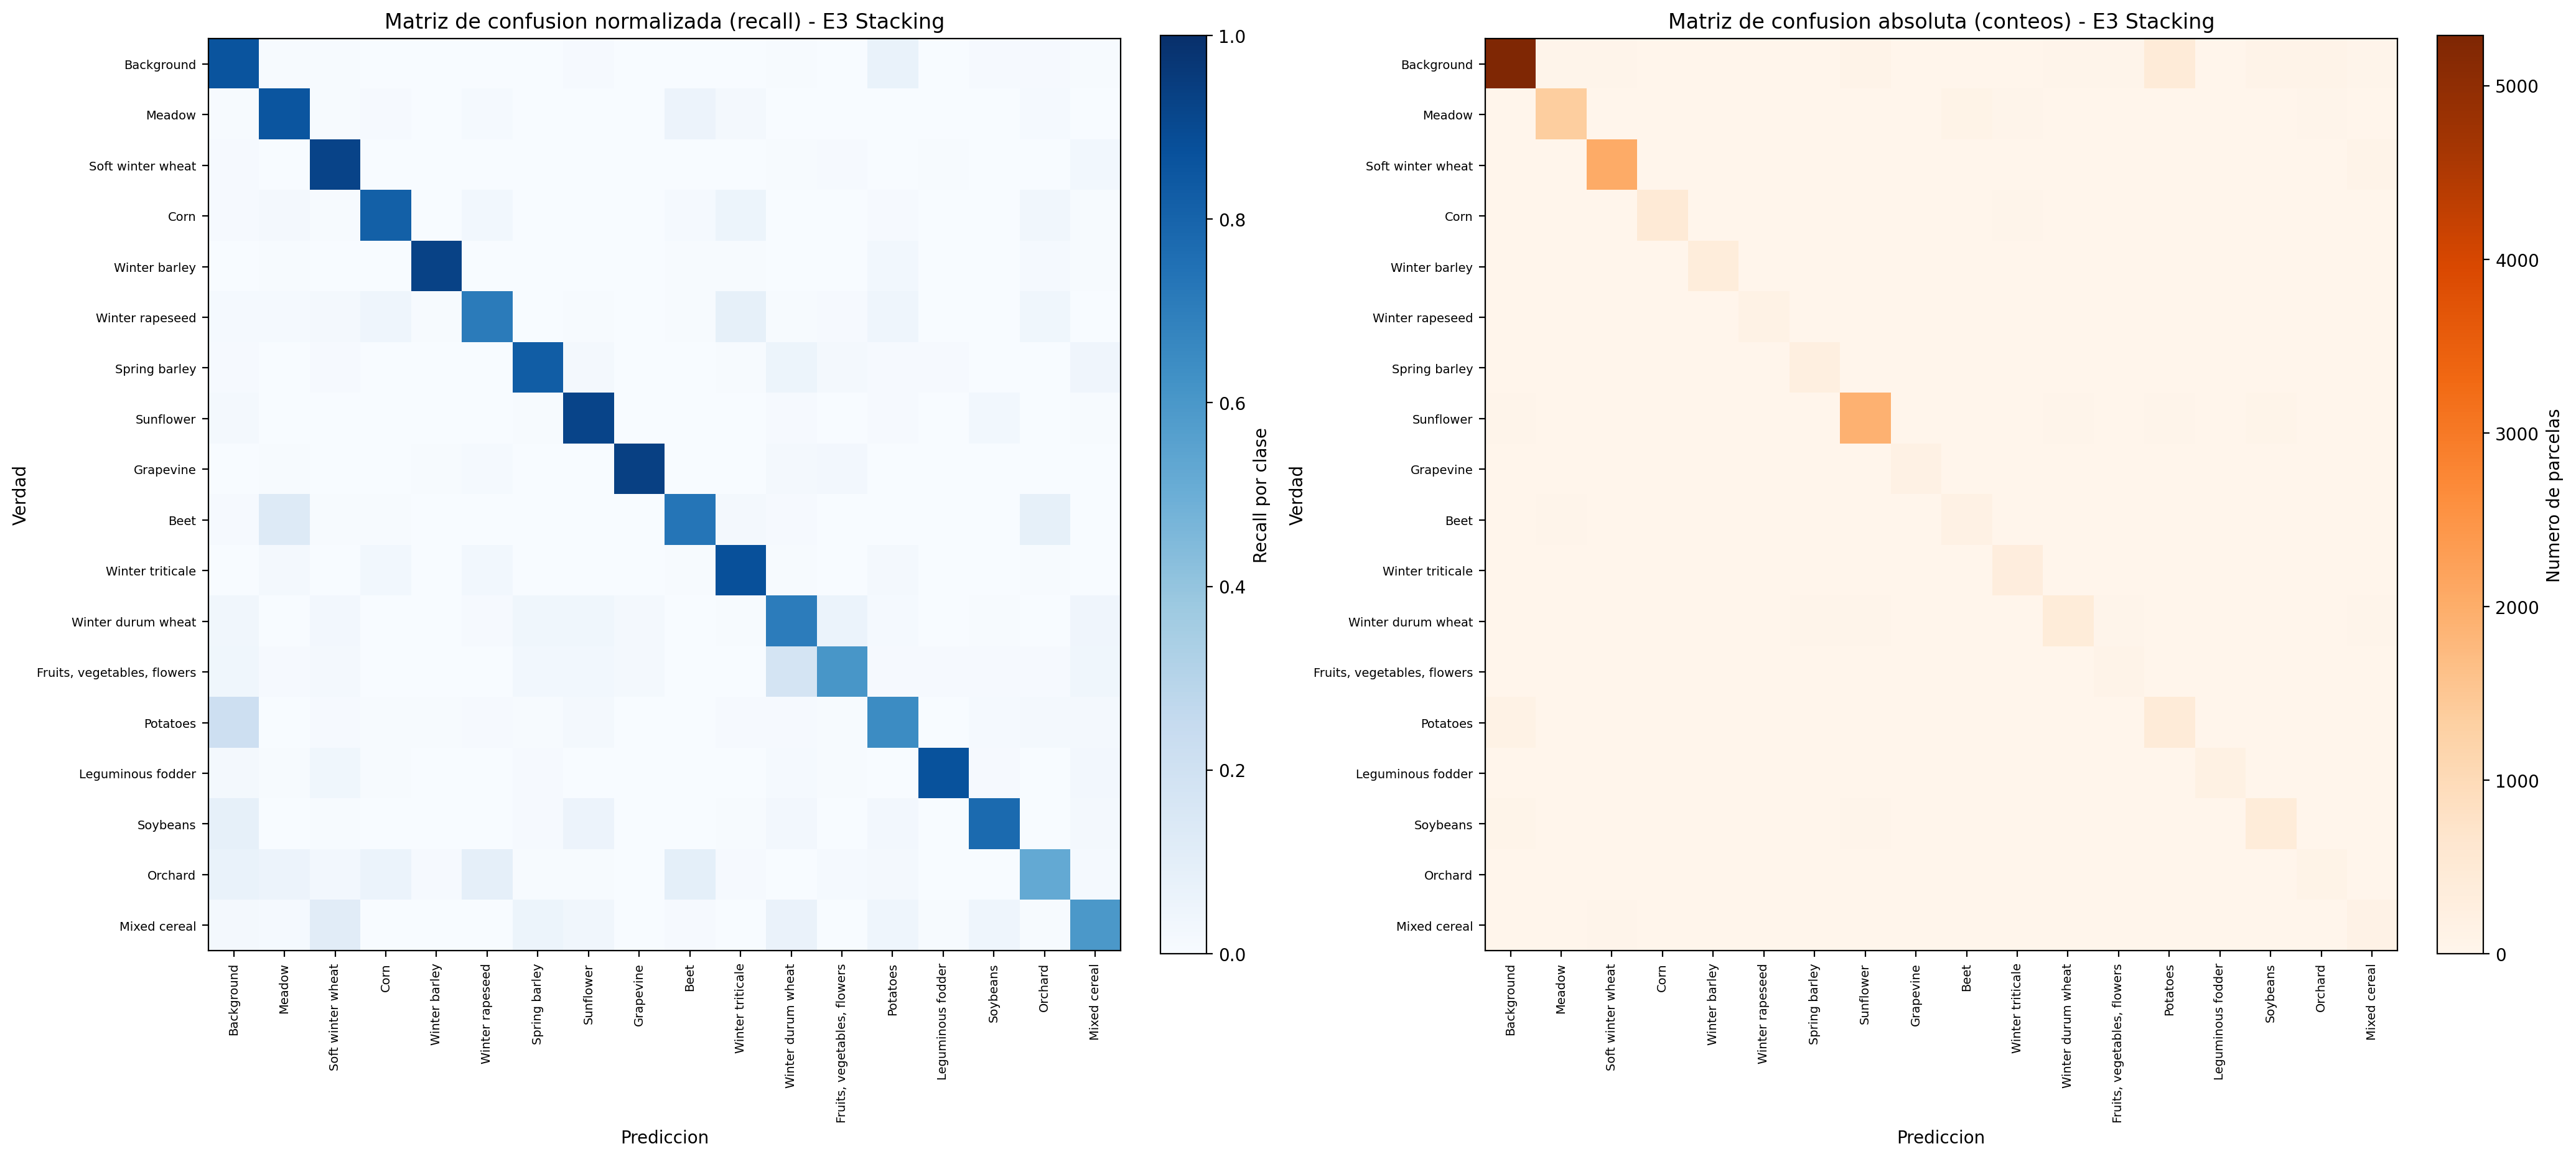

**Curva ROC una-vs-resto (macro-AUC 0.976)**

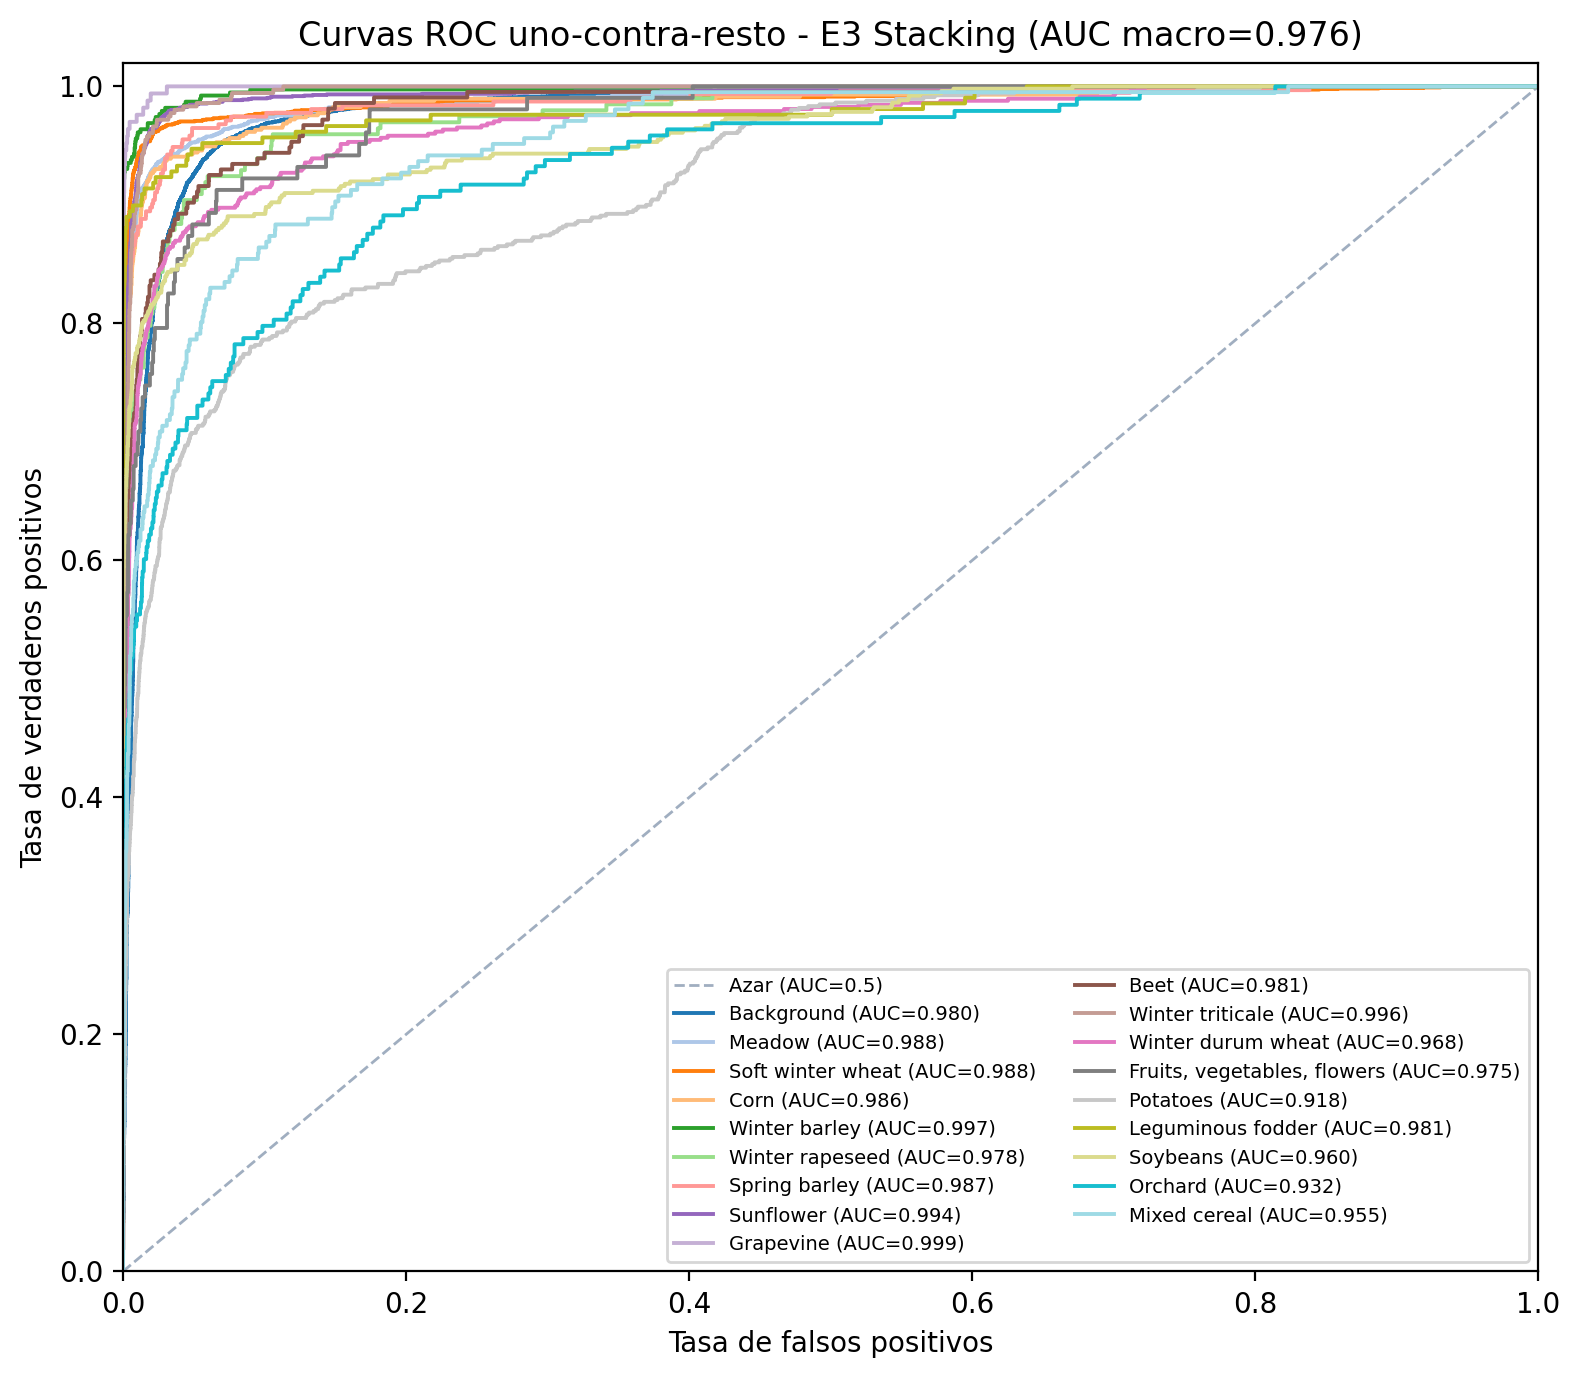

**Curva precision-exhaustividad (macro-AP 0.795)**

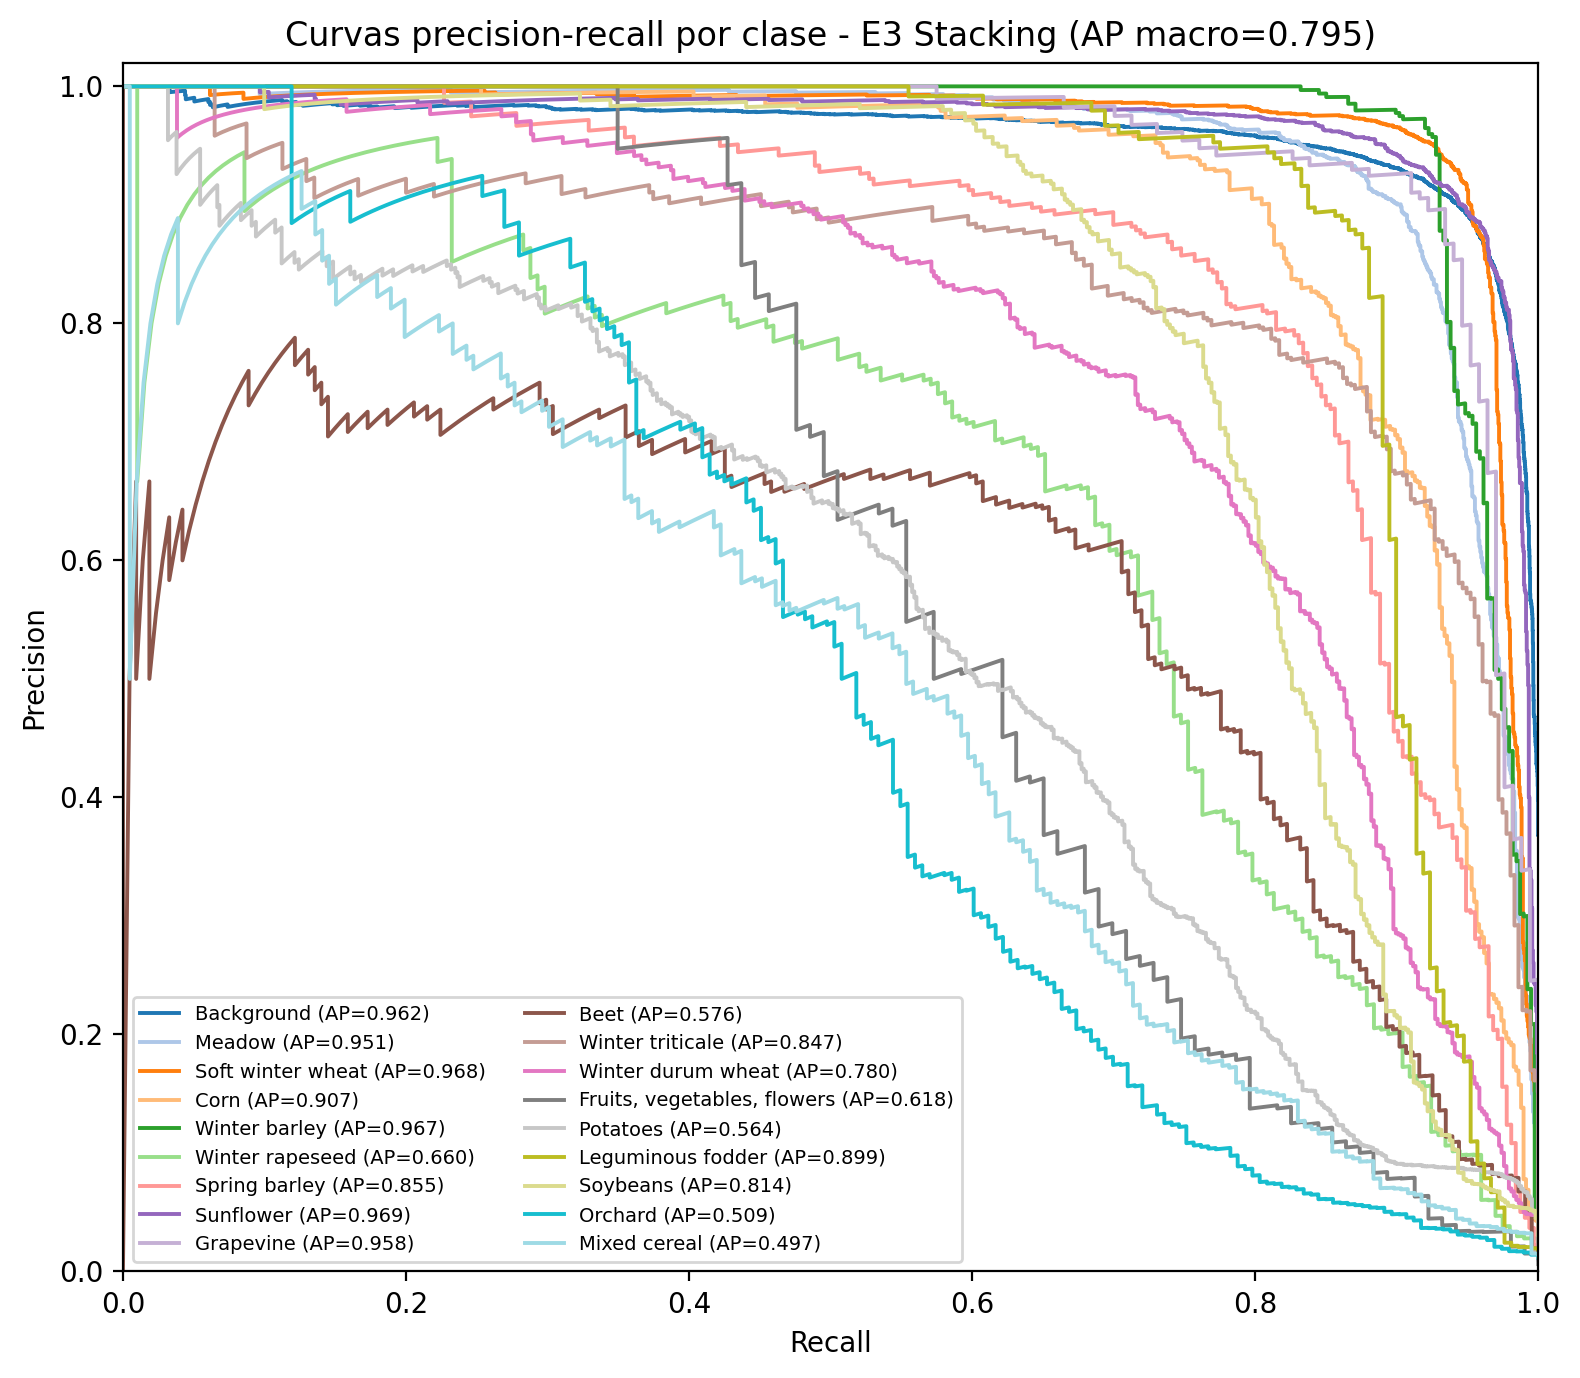

**Residuos espaciales del Blending**

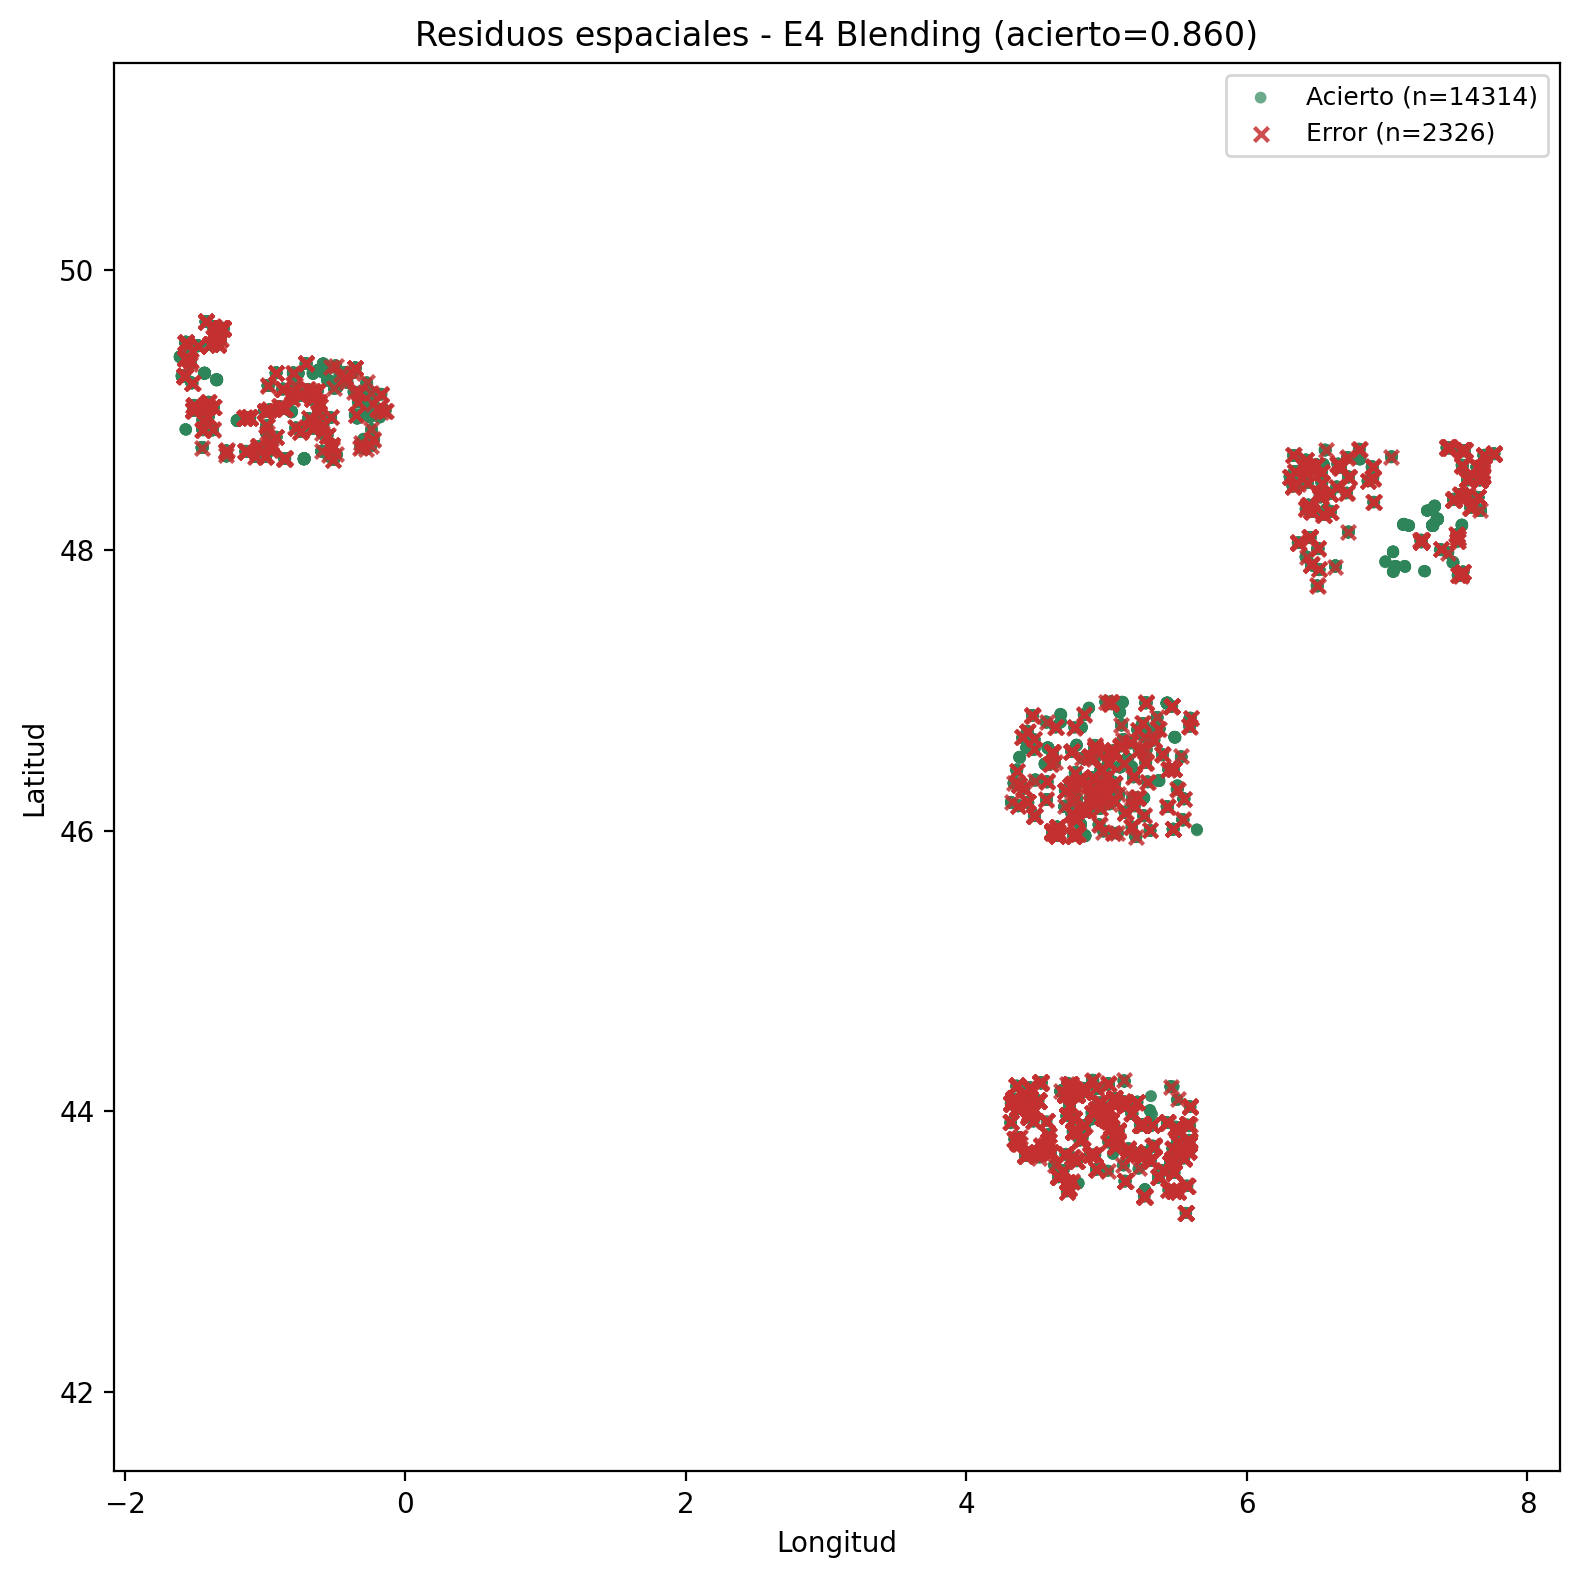

In [4]:
ens_figs = REPO / 'reports/ensemble/figures'
for fname, cap in [
    ('confusion_stacking.png', 'Matriz de confusion del Stacking elegido'),
    ('roc_ovr_stacking.png', 'Curva ROC una-vs-resto (macro-AUC 0.976)'),
    ('pr_stacking.png', 'Curva precision-exhaustividad (macro-AP 0.795)'),
    ('spatial_residuals_blending.png', 'Residuos espaciales del Blending'),
]:
    show_saved_png(ens_figs / fname, caption=cap)


## Conclusion del lote

- El **mejor segmentador individual** es el TSViT Full-M (US-038).
- El **mejor ensamble** es el Stacking heterogeneo (US-040, F1 0.747), que supera a cualquier modelo solo: la heterogeneidad denso+tabular es lo que aporta.
- En clasificacion patch (FarSLIP), el **techo real de PASTIS son ~4 clases**; AlphaEarth sigue siendo el embedding mas fuerte.
- Todo se reporto **sin sobre-afirmar**, con datos reales y anti-fuga.

Las tres notebooks (06a/06b/06c) dejan el lote US-030..US-040 completamente visualizado: predicciones reales, captions de Gemma, matrices de confusion y la comparativa de ensambles.